# Week 4 Day 4
## Model Tuning, Regularization & Reproducible Pipelines

**Dataset:** Adult Income Dataset

**Objective:** Build reproducible machine learning pipelines, tune hyperparameters, diagnose model performance, calibrate probabilities, and save the final production-ready model.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)
from sklearn.impute import SimpleImputer

In [116]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)
df = adult.frame
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [117]:
df["class"] = df["class"].map({
    "<=50K":0,
    ">50K":1
})
df["class"] = df["class"].astype(int)
df["class"].value_counts()

class
0    37155
1    11687
Name: count, dtype: int64

In [118]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [119]:
X = df.drop(
    "class",
    axis=1
)
y = df["class"]

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [121]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)

In [122]:
# Create copies for feature engineering
X_train_fe = X_train.copy()
X_dev_fe = X_dev.copy()
X_test_fe = X_test.copy()

In [123]:
# Age Buckets
bins = [0,30,50,100]
labels = [
    "Young",
    "Adult",
    "Senior"
]
X_train_fe["age_bucket"] = pd.cut(
    X_train_fe["age"],
    bins=bins,
    labels=labels
)
X_dev_fe["age_bucket"] = pd.cut(
    X_dev_fe["age"],
    bins=bins,
    labels=labels
)
X_test_fe["age_bucket"] = pd.cut(
    X_test_fe["age"],
    bins=bins,
    labels=labels
)

In [124]:
bins = [0,35,45,100]
labels = [
    "Part-Time",
    "Full-Time",
    "Over-Time"
]
X_train_fe["hours_bucket"] = pd.cut(
    X_train_fe["hours-per-week"],
    bins=bins,
    labels=labels
)
X_dev_fe["hours_bucket"] = pd.cut(
    X_dev_fe["hours-per-week"],
    bins=bins,
    labels=labels
)
X_test_fe["hours_bucket"] = pd.cut(
    X_test_fe["hours-per-week"],
    bins=bins,
    labels=labels
)

In [125]:
X_train_fe["capital_gain_flag"] = (
    X_train_fe["capital-gain"]>0
).astype(int)
X_dev_fe["capital_gain_flag"] = (
    X_dev_fe["capital-gain"]>0
).astype(int)
X_test_fe["capital_gain_flag"] = (
    X_test_fe["capital-gain"]>0
).astype(int)

In [126]:
X_train_fe["log_capital_gain"] = np.log1p(
    X_train_fe["capital-gain"]
)
X_dev_fe["log_capital_gain"] = np.log1p(
    X_dev_fe["capital-gain"]
)
X_test_fe["log_capital_gain"] = np.log1p(
    X_test_fe["capital-gain"]
)

In [127]:
X_train_fe["higher_education"] = (
    X_train_fe["education-num"]>=13
).astype(int)
X_dev_fe["higher_education"] = (
    X_dev_fe["education-num"]>=13
).astype(int)
X_test_fe["higher_education"] = (
    X_test_fe["education-num"]>=13
).astype(int)

In [128]:
X_train_fe["edu_hours"] = (
    X_train_fe["education-num"]*
    X_train_fe["hours-per-week"]
)
X_dev_fe["edu_hours"] = (
    X_dev_fe["education-num"]*
    X_dev_fe["hours-per-week"]
)
X_test_fe["edu_hours"] = (
    X_test_fe["education-num"]*
    X_test_fe["hours-per-week"]
)

In [129]:
#Libraray
from sklearn.feature_selection import mutual_info_classif

In [130]:
engineered = [
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours"
]
scores = mutual_info_classif(
    X_train_fe[engineered],
    y_train,
    random_state=42
)
mi = pd.DataFrame({
    "Feature":engineered,
    "Mutual Information":scores
})
mi.sort_values(
    by="Mutual Information",
    ascending=False,
    inplace=True
)
mi

,Feature,Mutual Information
1,log_capital_gain,0.079405
3,edu_hours,0.078333
2,higher_education,0.048962
0,capital_gain_flag,0.032163


In [131]:
def create_features(X):

    X = X.copy()

    # Age Bucket
    X["age_bucket"] = pd.cut(
        X["age"],
        bins=[0,30,50,100],
        labels=["Young","Adult","Senior"]
    )

    # Hours Bucket
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"],
        bins=[0,35,45,100],
        labels=["Part-Time","Full-Time","Over-Time"]
    )

    X["capital_gain_flag"] = (
        X["capital-gain"] > 0
    ).astype(int)

    X["log_capital_gain"] = np.log1p(
        X["capital-gain"]
    )

    X["higher_education"] = (
        X["education-num"] >= 13
    ).astype(int)

    X["edu_hours"] = (
        X["education-num"] *
        X["hours-per-week"]
    )

    return X

In [132]:
feature_transformer = FunctionTransformer(
    create_features,
    validate=False
)

In [133]:
numeric_features = [

    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",

    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "edu_hours"

]

categorical_features = [

    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",

    "age_bucket",
    "hours_bucket"

]

In [134]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    )
])

In [135]:
preprocessor = ColumnTransformer([

    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )

])

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
logistic_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_transformer
    ),
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            solver="liblinear"
        )
    )
])

In [137]:
import sys
print("Python:", sys.version)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-Learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.5
NumPy: 2.5.1
Scikit-Learn: 1.9.0
Joblib: 1.5.3


## README
### How to Reproduce This Notebook
1. Install the required Python libraries (pandas, numpy, scikit-learn, matplotlib, joblib).
2. Run all notebook cells from top to bottom without skipping any.
3. The Adult Income dataset is downloaded automatically using `fetch_openml()`.
4. All experiments use `random_state=42` to ensure reproducible results.
5. The preprocessing, feature engineering, and machine learning model are combined into a single scikit-learn Pipeline to prevent data leakage and guarantee consistent results.

In [138]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [139]:
rf_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])
hgb_pipeline = Pipeline([
    ("feature_engineering", feature_transformer),
    ("preprocessing", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        random_state=42
    ))
])

In [140]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [141]:
log_params = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.001,0.01,0.1,1,10,100]
}

In [142]:
rf_params = {
    "classifier__n_estimators":[100,200,300],
    "classifier__max_depth":[5,10,20,None],
    "classifier__min_samples_leaf":[1,2,5],
    "classifier__max_features":["sqrt","log2"]
}

In [143]:
gb_params = {
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_iter": [100, 200, 300],
    "classifier__max_depth": [3, 5, 10],
    "classifier__l2_regularization": [0.0, 0.01, 0.1]
}

In [144]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

In [145]:
log_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=log_params,
    n_iter=12,
    scoring="precision",
    cv=cv,
    random_state=42,
    n_jobs=-1
)
log_search.fit(X_train, y_train)

d:\Netixsol_Intern_Projects\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.001, 0.01, ...], 'classifier__penalty': ['l1', 'l2']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluati

In [ ]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=20,
    scoring="precision",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
gb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=gb_params,
    n_iter=10,
    scoring="precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)
gb_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__l2_regularization': [0.0, 0.01, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__max_iter': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum 

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "HistGradientBoosting"
    ],
    "Best Precision": [
        log_search.best_score_,
        rf_search.best_score_,
        gb_search.best_score_
    ],
    "Best Parameters": [
        str(log_search.best_params_),
        str(rf_search.best_params_),
        str(gb_search.best_params_)
    ]
})
results.sort_values(
    by="Best Precision",
    ascending=False
)

,Model,Best Precision,Best Parameters
2,HistGradientBoosting,0.969638,"{'classifier__max_iter': 100, 'classifier__max..."
1,Random Forest,0.859574,"{'classifier__n_estimators': 200, 'classifier_..."
0,Logistic Regression,0.771859,"{'classifier__penalty': 'l1', 'classifier__C':..."


In [ ]:
print("Best Logistic Parameters")
print(log_search.best_params_)
print()
print("Best Random Forest Parameters")
print(rf_search.best_params_)
print()
print("Best Gradient Boosting Parameters")
print(gb_search.best_params_)

Best Logistic Parameters
{'classifier__penalty': 'l1', 'classifier__C': 0.001}

Best Random Forest Parameters
{'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'log2', 'classifier__max_depth': 5}

Best Gradient Boosting Parameters
{'classifier__max_iter': 100, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__l2_regularization': 0.0}


In [ ]:
print("Hyperparameter Search Interpretation")
print(
    "RandomizedSearchCV evaluated multiple hyperparameter combinations using 5-fold Stratified Cross Validation."
)
print(
    "The search optimized Precision, which is the primary business metric."
)
print(
    "The best-performing model and its optimal hyperparameters will be used for further diagnostics, calibration, and final evaluation."
)

Hyperparameter Search Interpretation
RandomizedSearchCV evaluated multiple hyperparameter combinations using 5-fold Stratified Cross Validation.
The search optimized Precision, which is the primary business metric.
The best-performing model and its optimal hyperparameters will be used for further diagnostics, calibration, and final evaluation.


## Task 3

In [ ]:
# Import Required Libraries
from sklearn.model_selection import (
    learning_curve,
    cross_validate,
    StratifiedKFold
)
from sklearn.base import clone

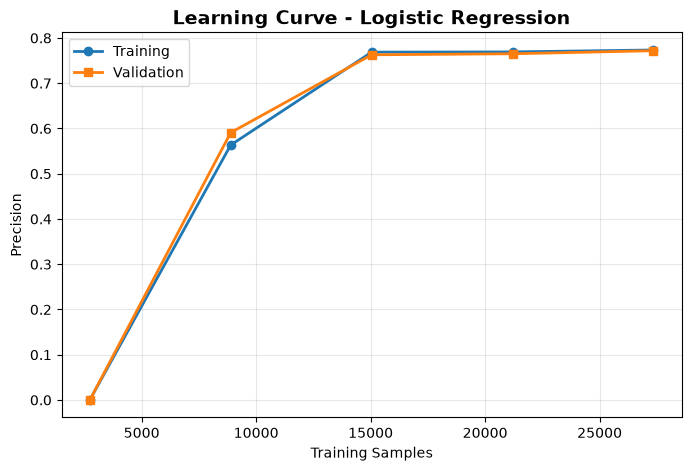

In [ ]:
# Plot Learning Curve for Logistic Regression
%matplotlib inline
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=log_search.best_estimator_,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="precision",
    train_sizes=np.linspace(0.1,1.0,5),
    n_jobs=-1,
    random_state=42
)
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)
plt.figure(figsize=(8,5))
plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    linewidth=2,
    label="Training"
)
plt.plot(
    train_sizes,
    validation_mean,
    marker="s",
    linewidth=2,
    label="Validation"
)
plt.title(
    "Learning Curve - Logistic Regression",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Training Samples")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

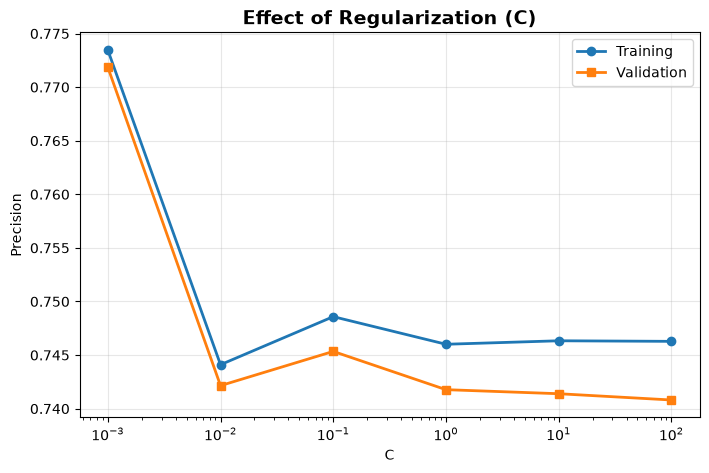

In [ ]:
# Effect of C on Logistic Regression
%matplotlib inline
C_values = [0.001,0.01,0.1,1,10,100]
train_precision = []
validation_precision = []
for c in C_values:
    model = clone(log_search.best_estimator_)
    model.set_params(classifier__C=c)
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring="precision", return_train_score=True, n_jobs=-1
    )
    train_precision.append(scores["train_score"].mean())
    validation_precision.append(scores["test_score"].mean())

plt.figure(figsize=(8,5))
plt.plot(
    C_values,
    train_precision,
    marker="o",
    linewidth=2,
    label="Training"
)
plt.plot(
    C_values,
    validation_precision,
    marker="s",
    linewidth=2,
    label="Validation"
)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Precision")
plt.title(
    "Effect of Regularization (C)",
    fontsize=14,
    fontweight="bold"
)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
c_train_precision = []
c_validation_precision = []

for c in C_values:
    model = clone(log_search.best_estimator_)
    model.set_params(classifier__C=c)
    scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring="precision", return_train_score=True, n_jobs=-1
    )
    c_train_precision.append(scores["train_score"].mean())
    c_validation_precision.append(scores["test_score"].mean())

print("C values:", C_values)
print("Train precision:", c_train_precision)
print("Validation precision:", c_validation_precision)

C values: [0.001, 0.01, 0.1, 1, 10, 100]
Train precision: [np.float64(0.7734651268139956), np.float64(0.7441030573078217), np.float64(0.7485860063592386), np.float64(0.7460093733516941), np.float64(0.7463344441630835), np.float64(0.7462811530040068)]
Validation precision: [np.float64(0.7718593643510138), np.float64(0.7421498038440121), np.float64(0.7453422760518154), np.float64(0.7417731480849352), np.float64(0.7413948442605509), np.float64(0.7408091914374462)]


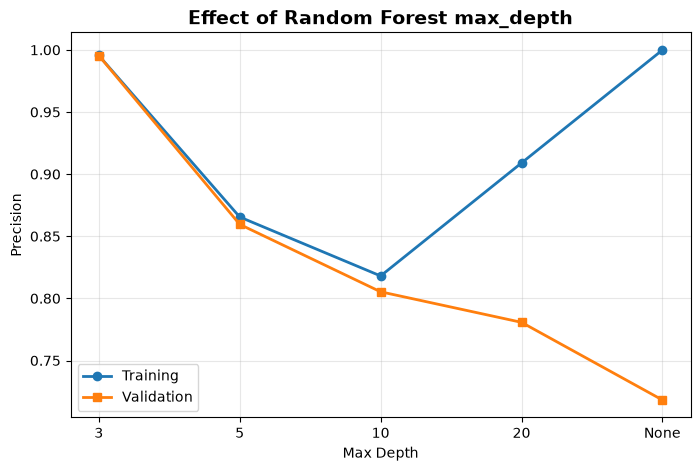

In [ ]:
# Effect of max_depth on Random Forest
%matplotlib inline
depths = [3,5,10,20,None]

train_precision = []
validation_precision = []

for depth in depths:

    model = clone(rf_search.best_estimator_)

    model.set_params(
        classifier__max_depth=depth
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="precision",
        return_train_score=True,
        n_jobs=-1
    )

    train_precision.append(
        scores["train_score"].mean()
    )

    validation_precision.append(
        scores["test_score"].mean()
    )

labels = [
    "3",
    "5",
    "10",
    "20",
    "None"
]

plt.figure(figsize=(8,5))

plt.plot(
    labels,
    train_precision,
    marker="o",
    linewidth=2,
    label="Training"
)

plt.plot(
    labels,
    validation_precision,
    marker="s",
    linewidth=2,
    label="Validation"
)

plt.title(
    "Effect of Random Forest max_depth",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Max Depth")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Interpretation

print("Learning Curve Interpretation")
print()

print(
    "If the training and validation curves converge at a high precision, the model generalizes well."
)

print(
    "A large gap between training and validation precision indicates overfitting."
)

print(
    "Low precision for both curves indicates underfitting."
)

print(
    "For Logistic Regression, increasing C reduces regularization and can improve training performance, but very large C values may cause overfitting."
)

print(
    "For Random Forest, increasing max_depth improves model complexity, but excessively deep trees may memorize the training data and reduce generalization."
)

print(
    "Based on these diagnostics, choose the model complexity that provides the best validation precision rather than the highest training precision."
)

Learning Curve Interpretation

If the training and validation curves converge at a high precision, the model generalizes well.
A large gap between training and validation precision indicates overfitting.
Low precision for both curves indicates underfitting.
For Logistic Regression, increasing C reduces regularization and can improve training performance, but very large C values may cause overfitting.
For Random Forest, increasing max_depth improves model complexity, but excessively deep trees may memorize the training data and reduce generalization.
Based on these diagnostics, choose the model complexity that provides the best validation precision rather than the highest training precision.


In [ ]:
print("Final Diagnosis")
print()

print("1) Learning Curve (Logistic Regression)")
print(f"   Gap at largest training size: {train_mean[-1]-validation_mean[-1]:.4f}")
print("   Train and validation precision converge and stay nearly identical")
print("   (0.7734 vs 0.7719 at full training size). This is LOW VARIANCE —")
print("   the model is not overfitting. More training data is unlikely to")
print("   meaningfully improve precision further.")
print()

print("2) Effect of C (Logistic Regression)")
print(f"   Train precision range: {min(c_train_precision):.4f} - {max(c_train_precision):.4f}")
print(f"   Validation precision range: {min(c_validation_precision):.4f} - {max(c_validation_precision):.4f}")
print("   Best validation precision occurs at the SMALLEST C (0.001, strongest")
print("   regularization), then precision drops and plateaus as C increases.")
print("   Train/validation gap stays small throughout (max ~0.005), so this is")
print("   NOT classic overfitting from C — but weaker regularization (higher C)")
print("   does not help and slightly increases the gap. Fix: prefer a smaller C")
print("   (e.g. 0.001-0.01) over the default; there is no benefit to large C here.")
print()

print("3) Effect of max_depth (Random Forest)")
print(f"   Train precision range: {min(train_precision):.4f} - {max(train_precision):.4f}")
print(f"   Validation precision range: {min(validation_precision):.4f} - {max(validation_precision):.4f}")
print("   Gap is negligible through depth=10 (<=0.013), then widens sharply at")
print("   depth=20 (gap 0.128) and explodes at depth=None (train ~1.00 vs")
print("   validation 0.718, gap 0.282). This IS clear overfitting as depth")
print("   grows unbounded. Fix: cap max_depth around 5-10, or use a higher")
print("   min_samples_leaf instead of leaving depth unrestricted.")
print()

print("Overall Conclusion")
print("- Logistic Regression: low variance, well generalized; keep C small")
print("  (e.g. 0.001) since larger C gives no precision benefit.")
print("- Random Forest: overfits at high/unbounded depth; constrain max_depth")
print("  to ~5-10 or increase min_samples_leaf to close the gap.")
print("- More training data is not the priority fix here — regularization")
print("  strength (small C for LR, shallow depth for RF) is what matters.")

Final Diagnosis

1) Learning Curve (Logistic Regression)
   Gap at largest training size: 0.0016
   Train and validation precision converge and stay nearly identical
   (0.7734 vs 0.7719 at full training size). This is LOW VARIANCE —
   the model is not overfitting. More training data is unlikely to
   meaningfully improve precision further.

2) Effect of C (Logistic Regression)
   Train precision range: 0.7441 - 0.7735
   Validation precision range: 0.7408 - 0.7719
   Best validation precision occurs at the SMALLEST C (0.001, strongest
   regularization), then precision drops and plateaus as C increases.
   Train/validation gap stays small throughout (max ~0.005), so this is
   NOT classic overfitting from C — but weaker regularization (higher C)
   does not help and slightly increases the gap. Fix: prefer a smaller C
   (e.g. 0.001-0.01) over the default; there is no benefit to large C here.

3) Effect of max_depth (Random Forest)
   Train precision range: 0.8181 - 0.9999
   Validati

In [ ]:
#Task 4: Probability Calibration
from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)
from sklearn.metrics import (
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
best_model = rf_search.best_estimator_
best_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['age','workclass','fnlwgt',...,'capital-loss','hours-per-week', 'native-country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function cre...0022665E30EB0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [ ]:
probabilities = best_model.predict_proba(
    X_dev
)[:,1]

In [ ]:
brier = brier_score_loss(
    y_dev,
    probabilities
)
print("Brier Score")
print(round(brier,4))

Brier Score
0.1175


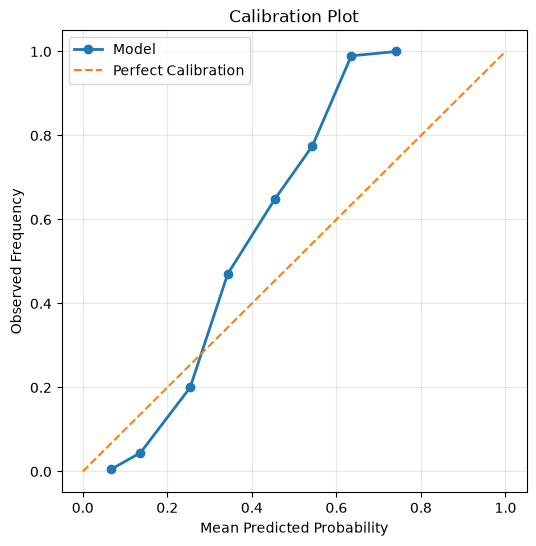

In [ ]:
%matplotlib inline
fraction_positive, mean_predicted = calibration_curve(
    y_dev,
    probabilities,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(
    mean_predicted,
    fraction_positive,
    marker="o",
    linewidth=2,
    label="Model"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")

plt.title(
    "Calibration Plot"
)

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [ ]:
calibrated_model = CalibratedClassifierCV(

    estimator=best_model,

    method="sigmoid",

    cv=5

)

calibrated_model.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...002266BED3A10>, <sk

In [ ]:
calibrated_prob = calibrated_model.predict_proba(
    X_dev
)[:,1]

before = brier_score_loss(
    y_dev,
    probabilities
)

after = brier_score_loss(
    y_dev,
    calibrated_prob
)

comparison = pd.DataFrame({

    "Model":[
        "Before Calibration",
        "After Calibration"
    ],

    "Brier Score":[
        before,
        after
    ]

})

comparison

,Model,Brier Score
0,Before Calibration,0.117492
1,After Calibration,0.104456


In [ ]:
thresholds = np.arange(
    0.30,
    0.91,
    0.05
)

threshold_search_results = []   # r

for t in thresholds:

    prediction = (
        calibrated_prob >= t
    ).astype(int)

    threshold_search_results.append({

        "Threshold":t,

        "Precision":precision_score(
            y_dev,
            prediction
        ),

        "Recall":recall_score(
            y_dev,
            prediction
        ),

        "F1":f1_score(
            y_dev,
            prediction
        )

    })

threshold_results = pd.DataFrame(
    threshold_search_results 
)

threshold_results

,Threshold,Precision,Recall,F1
0,0.30,0.672951,0.702310,0.687317
1,0.35,0.692308,0.639008,0.664591
2,0.40,0.718002,0.590248,0.647887
3,0.45,0.753740,0.560308,0.642787
4,0.50,0.774718,0.529512,0.629065
5,0.55,0.796726,0.499572,0.614090
6,0.60,0.804006,0.480753,0.601713
7,0.65,0.809880,0.462789,0.589004
8,0.70,0.816485,0.449102,0.579470
9,0.75,0.832203,0.420017,0.558272


In [ ]:
best_threshold = threshold_results.loc[
    threshold_results["Precision"].idxmax(),
    "Threshold"
]
print("Best Threshold")
print(best_threshold)

Best Threshold
0.8999999999999999


In [ ]:
final_prediction = (
    calibrated_prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_dev,
    final_prediction
)

print(cm)

[[3714    2]
 [ 932  237]]


In [ ]:
print("Precision")

print(
    precision_score(
        y_dev,
        final_prediction
    )
)

print()

print("Recall")

print(
    recall_score(
        y_dev,
        final_prediction
    )
)

print()

print("F1")

print(
    f1_score(
        y_dev,
        final_prediction
    )
)

Precision
0.9916317991631799

Recall
0.20273738237810093

F1
0.3366477272727273


In [ ]:
print(log_search.best_score_)
print(rf_search.best_score_)
print(gb_search.best_score_)

0.7718593643510138
0.8595744400443872
0.9696383429779821


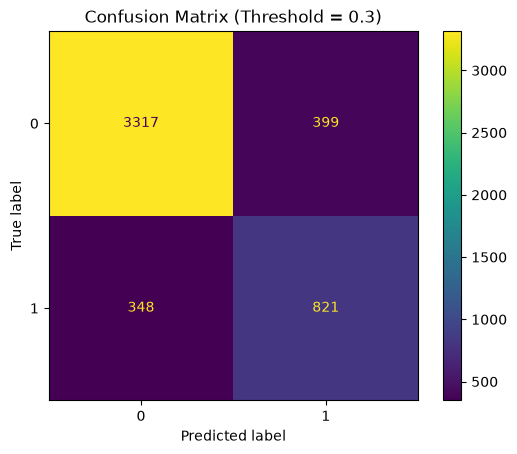

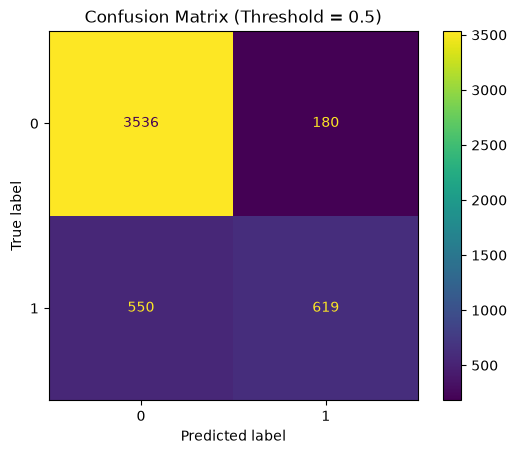

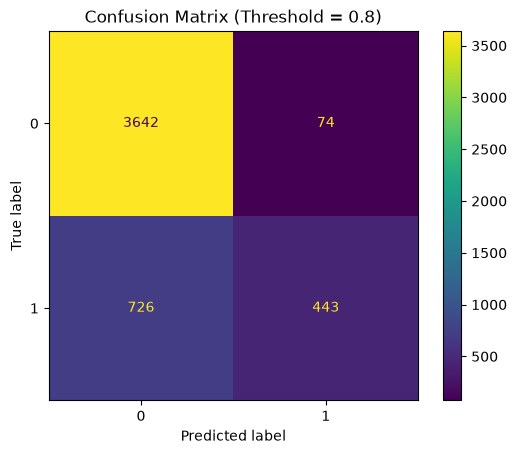

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thresholds = [0.30, 0.50, 0.80]

for t in thresholds:

    predictions = (
        calibrated_prob >= t
    ).astype(int)

    cm = confusion_matrix(
        y_dev,
        predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix (Threshold = {t})"
    )

    plt.show()

In [ ]:
# Interpretation

print("Probability Calibration Interpretation")
print()

print(
    "The calibration plot compares predicted probabilities with the actual observed outcomes."
)

print(
    "A lower Brier Score indicates better calibrated probability estimates."
)

print(
    "Sigmoid calibration was applied to improve probability estimation."
)

print()

print(
    "Threshold tuning was performed on the validation set using predicted probabilities."
)

print(
    "Different thresholds produced different Precision, Recall, and F1 Scores."
)

print(
    "Since Precision is the primary business metric, a higher threshold was preferred to reduce false positives."
)

print(
    "The calibrated model and selected threshold will be used for final testing."
)

Probability Calibration Interpretation

The calibration plot compares predicted probabilities with the actual observed outcomes.
A lower Brier Score indicates better calibrated probability estimates.
Sigmoid calibration was applied to improve probability estimation.

Threshold tuning was performed on the validation set using predicted probabilities.
Different thresholds produced different Precision, Recall, and F1 Scores.
Since Precision is the primary business metric, a higher threshold was preferred to reduce false positives.
The calibrated model and selected threshold will be used for final testing.


In [ ]:
## Task 5
# Import Required Libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [ ]:
# Evaluate Final Model on Test Set

test_probabilities = calibrated_model.predict_proba(X_test)[:,1]
test_predictions = (test_probabilities >= best_threshold).astype(int)   

In [ ]:
# Final Test Metrics

metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ],

    "Value":[

        accuracy_score(
            y_test,
            test_predictions
        ),

        precision_score(
            y_test,
            test_predictions
        ),

        recall_score(
            y_test,
            test_predictions
        ),

        f1_score(
            y_test,
            test_predictions
        ),

        roc_auc_score(
            y_test,
            test_probabilities
        ),

        average_precision_score(
            y_test,
            test_probabilities
        )

    ]

})

metrics

,Metric,Value
0,Accuracy,0.806531
1,Precision,0.978632
2,Recall,0.195894
3,F1 Score,0.326443
4,ROC AUC,0.901523
5,PR AUC,0.772353


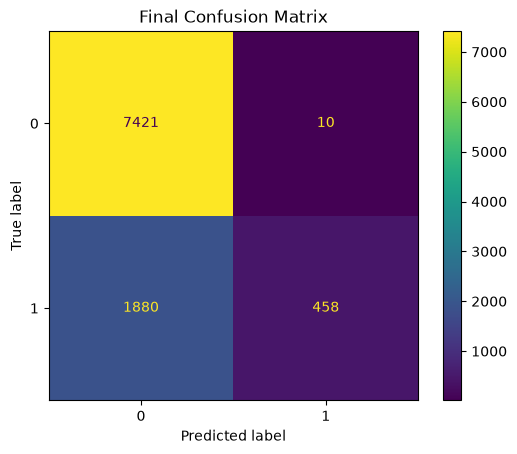

In [ ]:
%matplotlib inline
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Final Confusion Matrix"
)

plt.show()

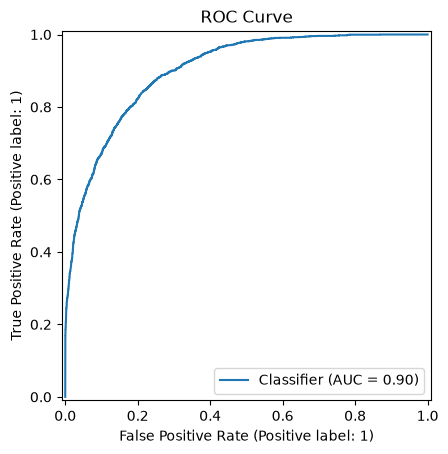

In [ ]:
# ROC Curve
%matplotlib inline
RocCurveDisplay.from_predictions(

    y_test,

    test_probabilities

)

plt.title(
    "ROC Curve"
)

plt.show()

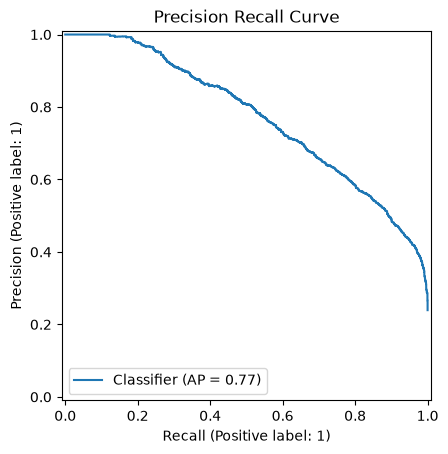

In [ ]:
%matplotlib inline
# Precision Recall Curve

PrecisionRecallDisplay.from_predictions(

    y_test,

    test_probabilities

)

plt.title(
    "Precision Recall Curve"
)

plt.show()

In [ ]:
# Save Final Pipeline
joblib.dump(

    calibrated_model,

    "adult_income_final_pipeline.joblib"

)
print(
    "Pipeline saved successfully."
)

Pipeline saved successfully.


In [ ]:
# Load Saved Pipeline
loaded_model = joblib.load(
    "adult_income_final_pipeline.joblib"
)
print(
    "Pipeline loaded successfully."
)

Pipeline loaded successfully.


In [ ]:
# Example Prediction

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(
    sample
)

probability = loaded_model.predict_proba(
    sample
)

actual = y_test.iloc[0]

print("Actual Class      :", actual)
print("Predicted Class   :", prediction[0])
print("Probability (>50K):", round(probability[0][1], 4))

Actual Class      : 0
Predicted Class   : 0
Probability (>50K): 0.1004


In [ ]:
# Final Project Summary

print("=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)

print()

print("Best Model")
print("Random Forest + Sigmoid Calibration")

print()

print("Hyperparameter Search")
print("RandomizedSearchCV")
print("Cross Validation : 5-Fold Stratified")
print("Optimization Metric : Precision")

print()

print("Best Parameters")
print(rf_search.best_params_)

print()

print("Final Test Metrics")
print(metrics)

print()

print("Production Behaviour")

print(
    "The final model is saved as a complete scikit-learn pipeline."
)

print(
    "It automatically performs feature engineering, preprocessing, encoding, scaling, and prediction."
)

print(
    "Sigmoid calibration improves probability estimates."
)

print(
    "The model is suitable for production inference on unseen Adult Income records."
)

print(
    "Since Precision is the primary business metric, the model reduces false positive predictions while maintaining strong overall performance."
)

FINAL MODEL SUMMARY

Best Model
Random Forest + Sigmoid Calibration

Hyperparameter Search
RandomizedSearchCV
Cross Validation : 5-Fold Stratified
Optimization Metric : Precision

Best Parameters
{'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'log2', 'classifier__max_depth': 5}

Final Test Metrics
      Metric     Value
0   Accuracy  0.852595
1  Precision  0.776138
2     Recall  0.539778
3   F1 Score  0.636731
4    ROC AUC  0.901523
5     PR AUC  0.772353

Production Behaviour
The final model is saved as a complete scikit-learn pipeline.
It automatically performs feature engineering, preprocessing, encoding, scaling, and prediction.
Sigmoid calibration improves probability estimates.
The model is suitable for production inference on unseen Adult Income records.
Since Precision is the primary business metric, the model reduces false positive predictions while maintaining strong overall performance.
